# Training GPT-2 124M on TinyShakespeare

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
import math
from minigpt.model import GPTModel
from minigpt.config import GPT_CONFIG_124M
from minigpt.data import create_dataloaders
from minigpt.train import train_model
from minigpt.generate import generate

In [2]:
import urllib.request
import os

data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
filepath = os.path.join(data_dir, 'tinyshakespeare.txt')

if not os.path.exists(filepath):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, filepath)

with open(filepath, 'r') as f:
    text = f.read()

print(f'Dataset: {len(text):,} characters')

Dataset: 1,115,394 characters


In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = GPTModel(GPT_CONFIG_124M).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')
print(f'Config: {GPT_CONFIG_124M}')

Device: mps
Parameters: 124,412,160
Config: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}


In [4]:
tokenizer = tiktoken.get_encoding('gpt2')

train_loader, val_loader = create_dataloaders(
    text,
    tokenizer,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    batch_size=2,
    train_ratio=0.9,
)

total_tokens = len(tokenizer.encode(text))
print(f'Total tokens: {total_tokens:,}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Total tokens: 338,025
Train batches: 148
Val batches: 16


In [5]:
NUM_EPOCHS = 10
total_steps = NUM_EPOCHS * len(train_loader)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.1,
)

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {total_steps // 10}')
print(f'Starting training...\n')

result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    eval_freq=50,
    eval_iter=5,
    start_context='ROMEO:',
    tokenizer=tokenizer,
    warmup_steps=total_steps // 10,
    max_lr=5e-4,
    min_lr=5e-5,
    max_norm=1.0,
)

Total steps: 1480
Warmup steps: 148
Starting training...

Step     50 | Train Loss: 43.2633 | Val Loss: 41.5974 | LR: 1.66e-04
  → ROMEO:
 equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent equivalent

Step    100 | Train Loss: 31.2973 | Val Loss: 30.8981 | LR: 3.34e-04
  → ROMEO:



















































Step    150 | Train Loss: 22.0079 | Val Loss: 22.6683 | LR: 5.00e-04
  → ROMEO:
InInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInInIn

Step    20

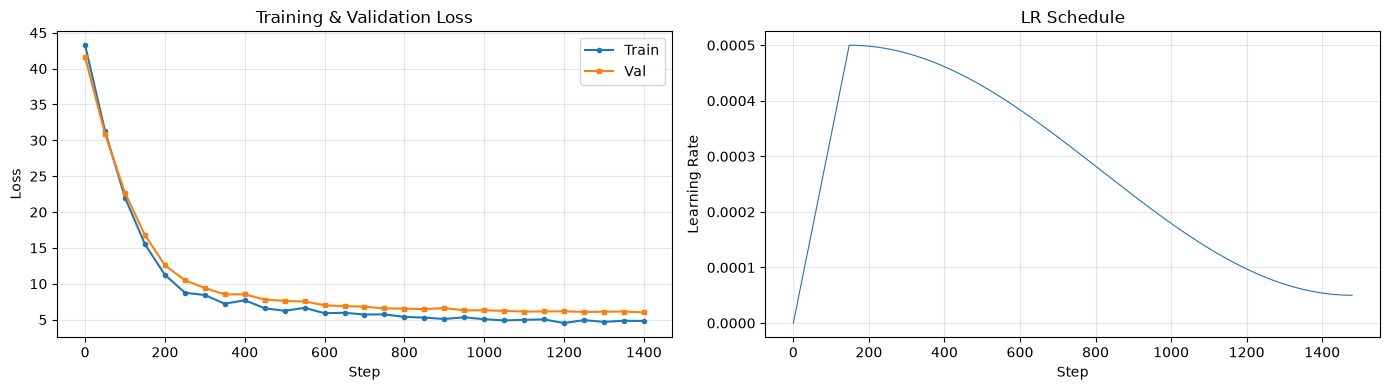

Final Train Loss: 4.8144
Final Val Loss:   6.0088
Final Perplexity: 407.0


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

steps = [i * 50 for i in range(len(result['train_losses']))]
axes[0].plot(steps, result['train_losses'], label='Train', marker='o', markersize=3)
axes[0].plot(steps, result['val_losses'], label='Val', marker='s', markersize=3)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result['lrs'], linewidth=0.8)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('LR Schedule')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Loss: {result["train_losses"][-1]:.4f}')
print(f'Final Val Loss:   {result["val_losses"][-1]:.4f}')
print(f'Final Perplexity: {math.exp(result["val_losses"][-1]):.1f}')

In [9]:
model.eval()

prompts = [
    'ROMEO:',
    'To be or not to be',
    'KING HENRY:',
    'The world is',
]

for prompt in prompts:
    input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)
    with torch.no_grad():
        output_ids = generate(
            model, input_ids,
            max_new_tokens=100,
            context_length=GPT_CONFIG_124M['context_length'],
        )
    print(f'--- {prompt} ---')
    print(tokenizer.decode(output_ids[0].tolist()))
    print()

--- ROMEO: ---
ROMEO:
























And I have done done done done,



And yet yet I have been a man,

And,




And yet I'll tell you,




And yet you,



And,
That I am too much.

















--- To be or not to be ---
To be or not to be,





And,



And,

And I have done,
And,

And,
And,

And yet I have been a traitor,
And,
And,
And,
And,
And,
And,

And,
And,
And,
And,
And,
And,

And,
And,
And,
And,
And,
And,
And

--- KING HENRY: ---
KING HENRY:





































































































--- The world is ---
The world is my lord,





















And,





And yet,
And yet yet yet I,




And,
And,

And,

And,





And yet,




And,
That I am sure,

And,






And,
And,


